In [1]:
import sys

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.gridspec as gridspec
import seaborn as sns
from pathlib import Path


project_root = Path().resolve().parent
sys.path.append(str(project_root))

In [2]:
from utils.savePlots import save

In [3]:
DATA_PATH   = "../data/processed/main_data.csv"

PALETTE     = "coolwarm"
FIG_SIZE    = (14, 6)
STYLE       = "seaborn-v0_8-whitegrid"
plt.style.use(STYLE)

In [4]:
df = pd.read_csv(DATA_PATH, parse_dates=["Date"])
df = df.sort_values("Date").reset_index(drop=True)
print(f"Loaded: {df.shape[0]} rows × {df.shape[1]} cols\n")

Loaded: 432 rows × 28 cols



  Saved ../results/eda/01_missing_values.png


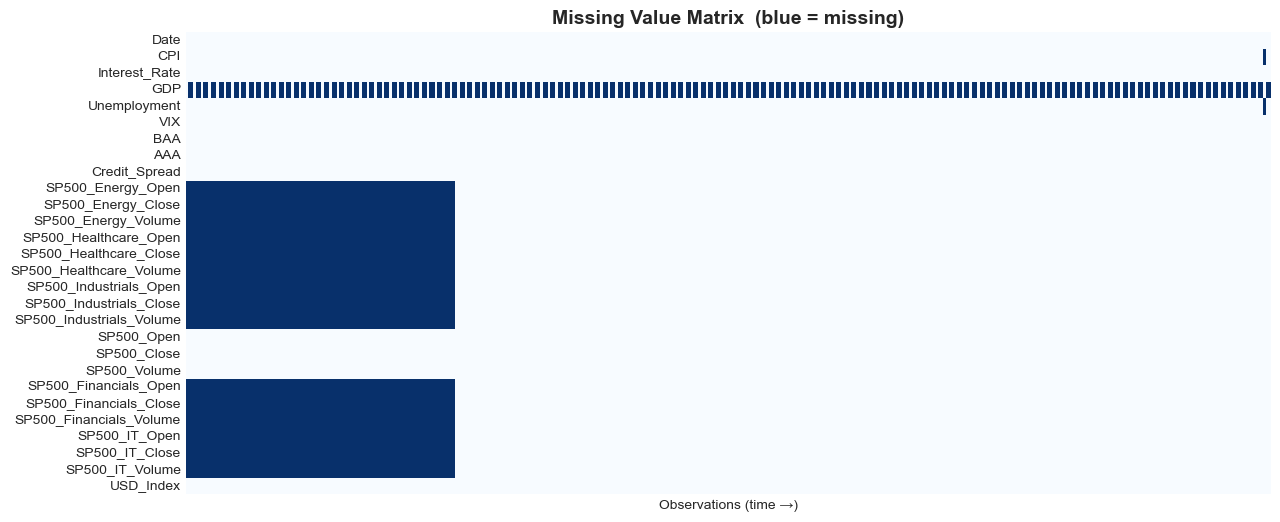

In [5]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
missing = df.isnull().astype(int)
sns.heatmap(missing.T, cmap="Blues", cbar=False, ax=ax,
            yticklabels=df.columns, xticklabels=False)
ax.set_title("Missing Value Matrix  (blue = missing)", fontsize=14, fontweight="bold")
ax.set_xlabel("Observations (time →)")
save("01_missing_values", "eda")
plt.show()


  Saved ../results/eda/02_sp500_close_timeseries.png


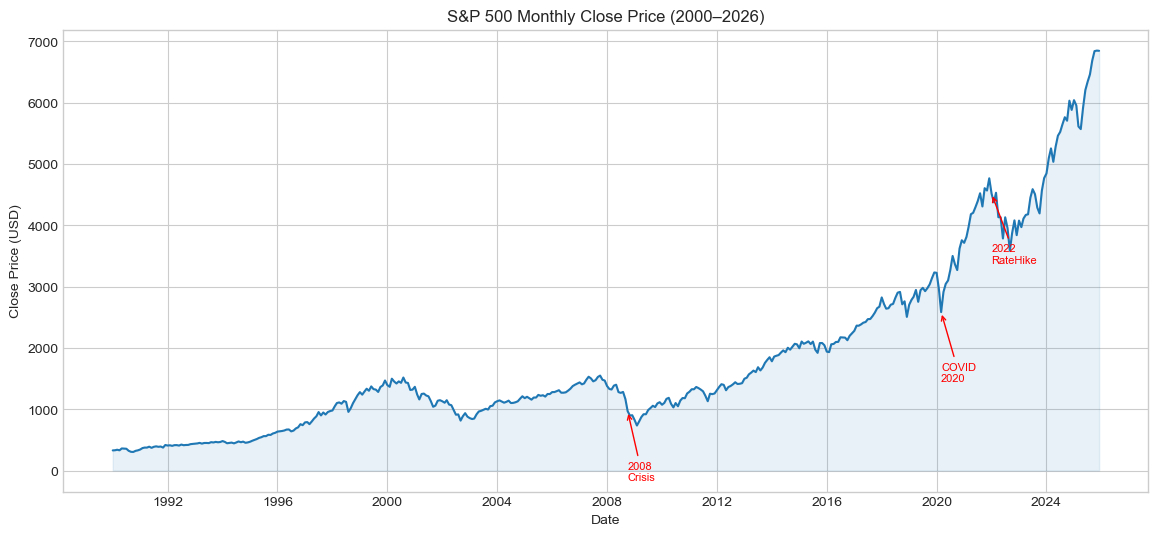

In [6]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
ax.plot(df["Date"], df["SP500_Close"], color="#1f77b4", linewidth=1.5)
ax.fill_between(df["Date"], df["SP500_Close"], alpha=0.1, color="#1f77b4")
ax.set(title="S&P 500 Monthly Close Price (2000–2026)",
       xlabel="Date", ylabel="Close Price (USD)")

# Annotate key events
events = {
    "2008\nCrisis": "2008-10-01",
    "COVID\n2020":  "2020-03-01",
    "2022\nRateHike": "2022-01-01",
}
for label, date in events.items():
    x = pd.Timestamp(date)
    y = df.loc[df["Date"] == x, "SP500_Close"]
    if not y.empty:
        ax.annotate(label, xy=(x, y.values[0]), xytext=(0, -50),
                    textcoords="offset points", fontsize=8,
                    arrowprops=dict(arrowstyle="->", color="red"), color="red")
save("02_sp500_close_timeseries","eda")
plt.show()




  Saved ../results/eda/03_macro_timeseries_panel.png


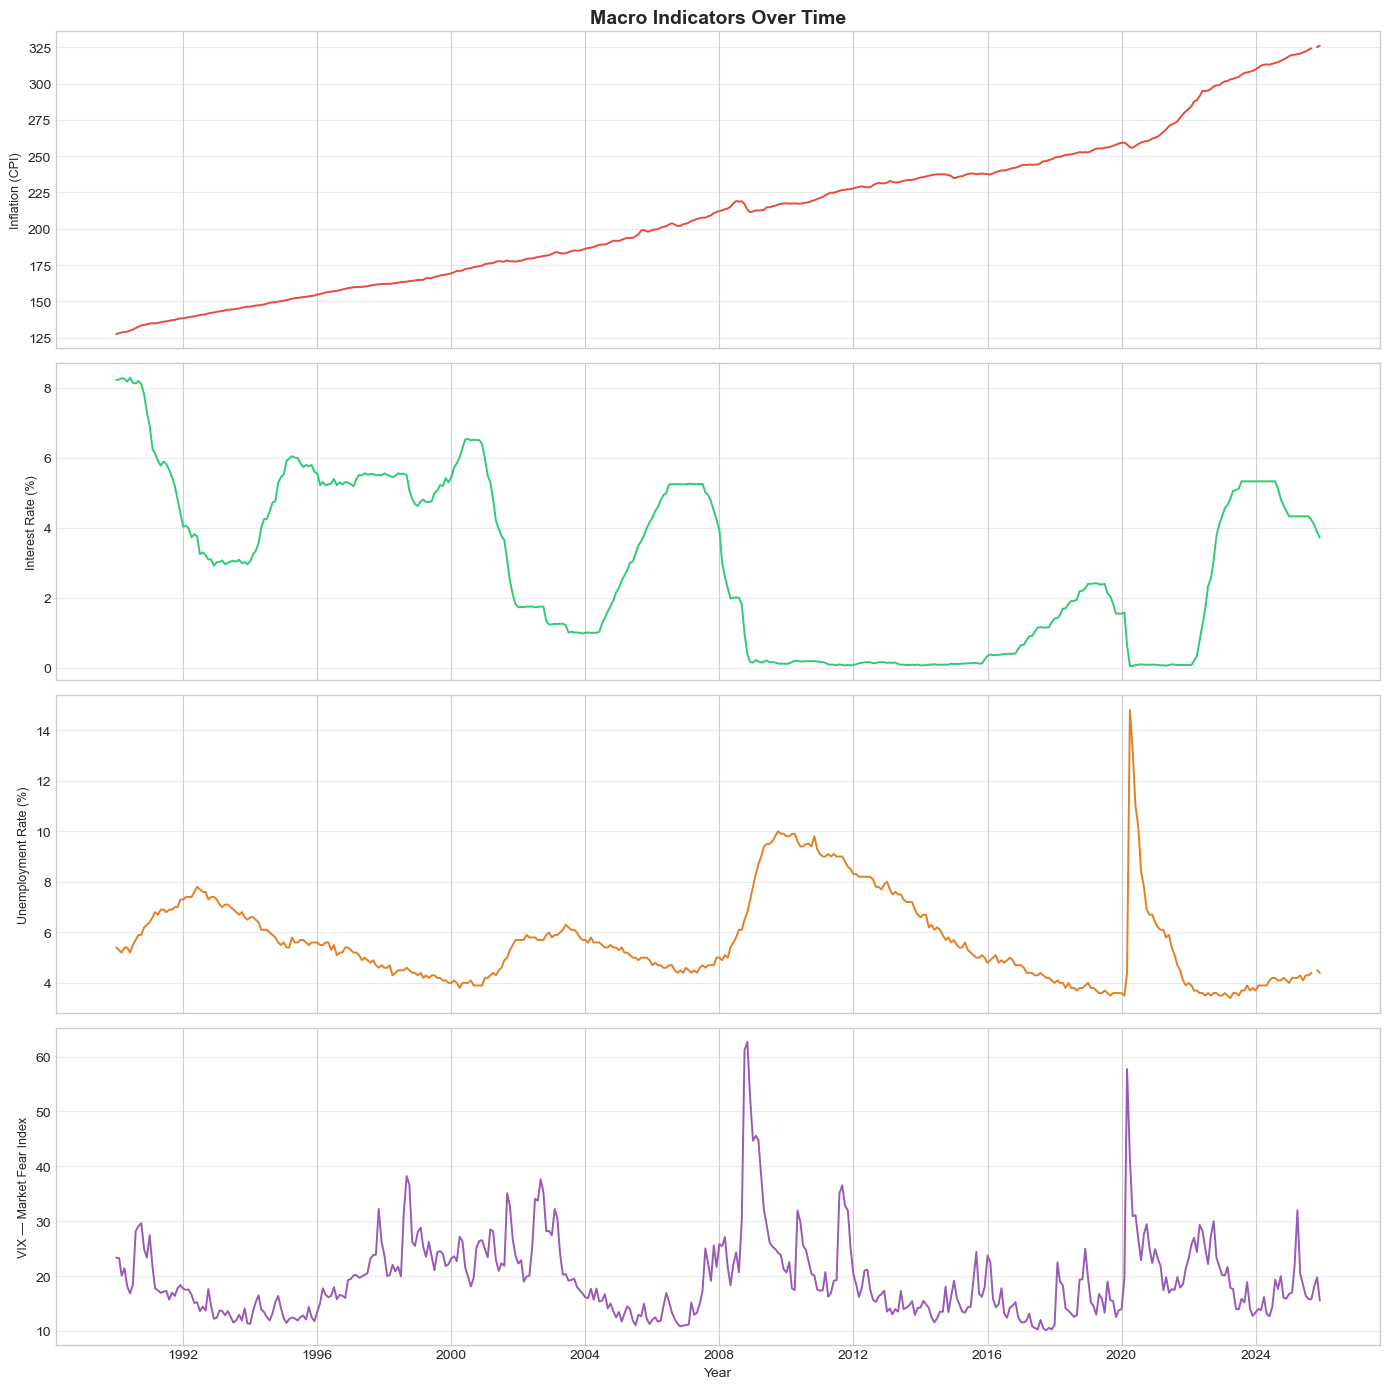

In [7]:
macro_vars = {
    "CPI":           "Inflation (CPI)",
    "Interest_Rate": "Interest Rate (%)",
    "Unemployment":  "Unemployment Rate (%)",
    "VIX":           "VIX — Market Fear Index",
}
fig, axes = plt.subplots(4, 1, figsize=(14, 14), sharex=True)
colors = ["#e74c3c", "#2ecc71", "#e67e22", "#9b59b6"]

for ax, (col, label), color in zip(axes, macro_vars.items(), colors):
    ax.plot(df["Date"], df[col], color=color, linewidth=1.4)
    ax.set_ylabel(label, fontsize=9)
    ax.grid(axis="y", alpha=0.4)

axes[0].set_title("Macro Indicators Over Time", fontsize=14, fontweight="bold")
axes[-1].set_xlabel("Year")
plt.tight_layout()
save("03_macro_timeseries_panel", "eda")
plt.show()

  Saved ../results/eda/04_interest_rates_comparison.png


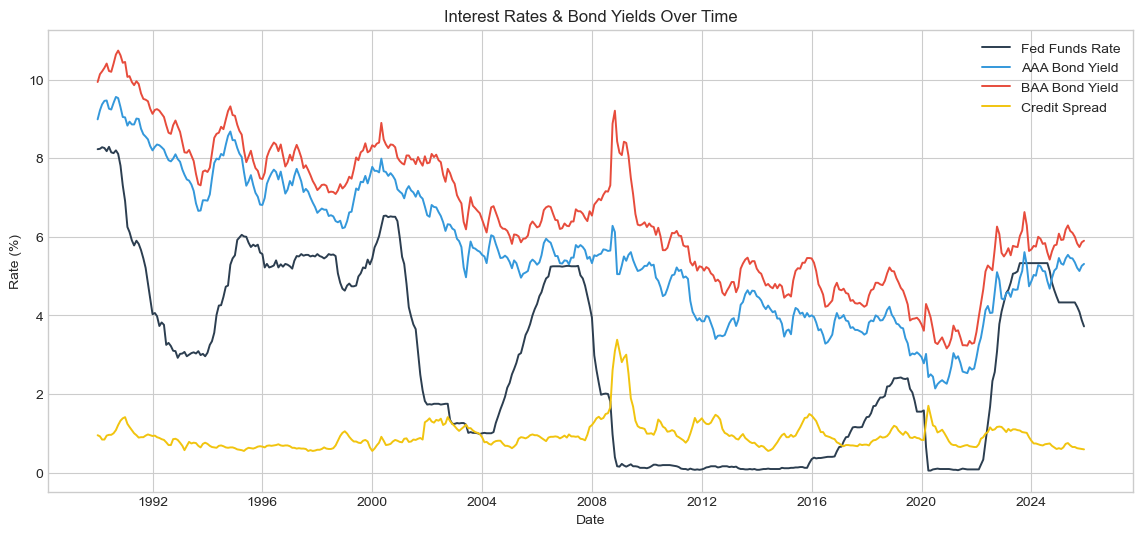

In [8]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
for col, color, label in zip(
    ["Interest_Rate", "AAA", "BAA", "Credit_Spread"],
    ["#2c3e50", "#3498db", "#e74c3c", "#f1c40f"],
    ["Fed Funds Rate", "AAA Bond Yield", "BAA Bond Yield", "Credit Spread"]
):
    ax.plot(df["Date"], df[col], color=color, linewidth=1.4, label=label)

ax.set(title="Interest Rates & Bond Yields Over Time",
       xlabel="Date", ylabel="Rate (%)")
ax.legend()
save("04_interest_rates_comparison","eda")
plt.show()

  Saved ../results/eda/05_distributions.png


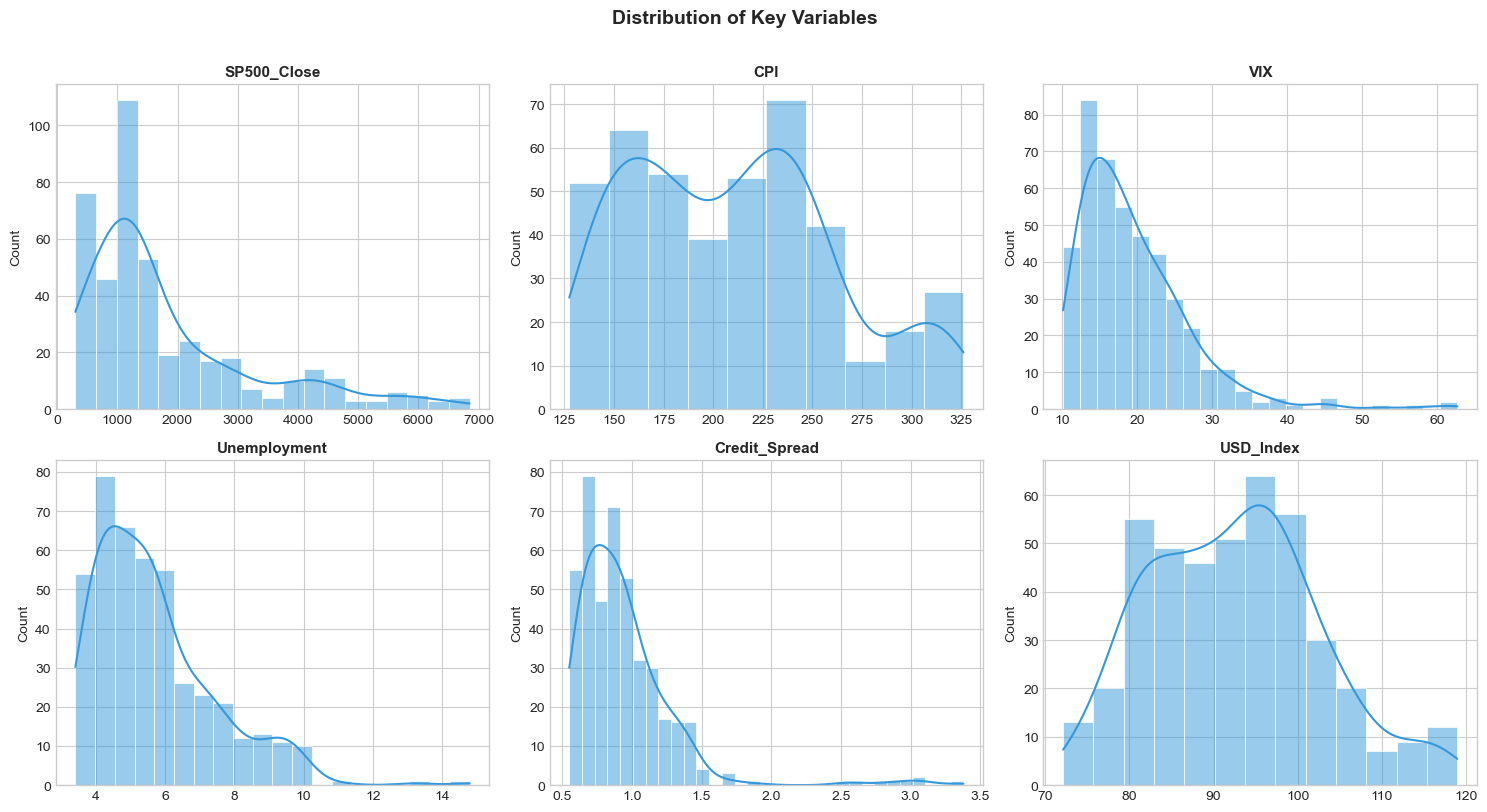

In [9]:
dist_vars = ["SP500_Close", "CPI", "VIX", "Unemployment", "Credit_Spread", "USD_Index"]
fig, axes = plt.subplots(2, 3, figsize=(15, 8))
axes = axes.flatten()

for ax, col in zip(axes, dist_vars):
    sns.histplot(df[col], kde=True, ax=ax,
                 color="#3498db", edgecolor="white", linewidth=0.5)
    ax.set_title(col, fontsize=11, fontweight="bold")
    ax.set_xlabel("")

plt.suptitle("Distribution of Key Variables", fontsize=14,
             fontweight="bold", y=1.01)
plt.tight_layout()
save("05_distributions","eda")
plt.show()


  Saved ../results/eda/06_correlation_heatmap.png


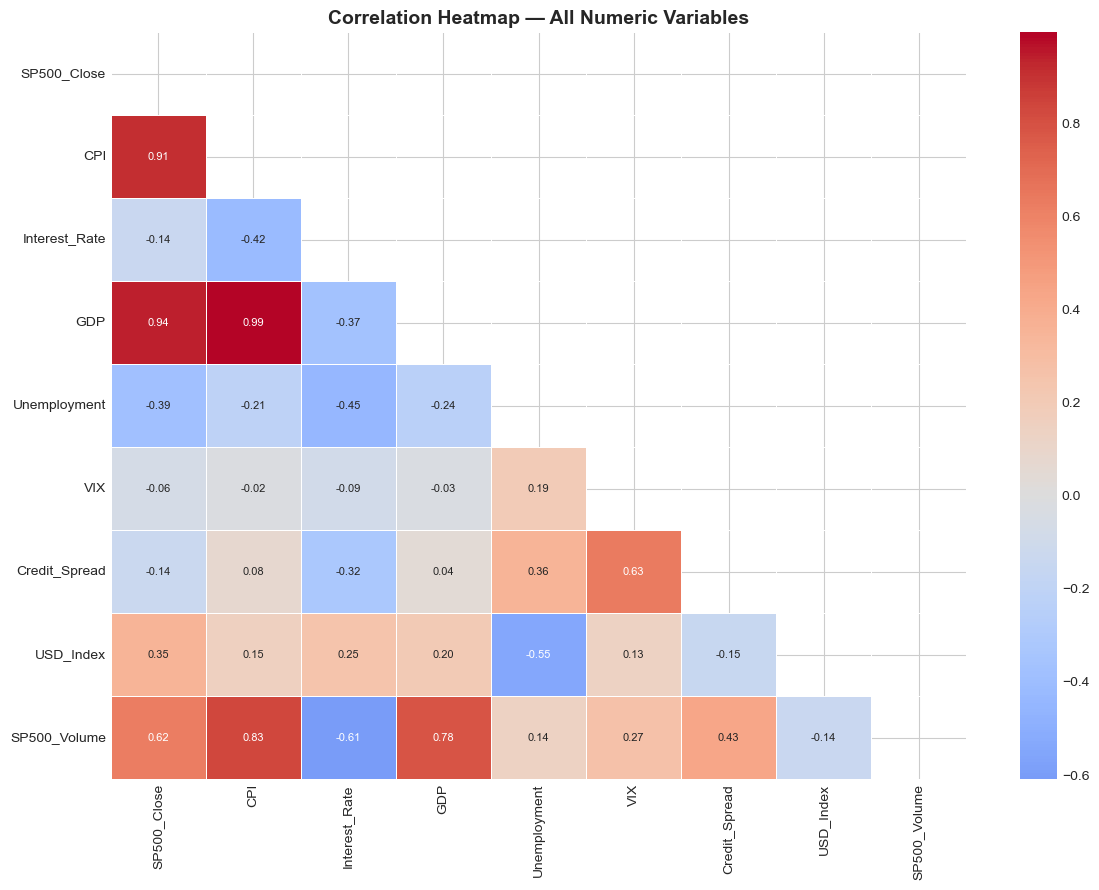

In [10]:
numeric_cols = ["SP500_Close", "CPI", "Interest_Rate", "GDP", "Unemployment",
                "VIX", "Credit_Spread", "USD_Index", "SP500_Volume"]
corr = df[numeric_cols].corr()

fig, ax = plt.subplots(figsize=(12, 9))
mask = pd.DataFrame(False, index=corr.index, columns=corr.columns)
# mask upper triangle to avoid duplication
import numpy as np
mask_arr = np.triu(np.ones_like(corr, dtype=bool))
sns.heatmap(corr, mask=mask_arr, annot=True, fmt=".2f",
            cmap=PALETTE, center=0, linewidths=0.5,
            ax=ax, annot_kws={"size": 8})
ax.set_title("Correlation Heatmap — All Numeric Variables",
             fontsize=14, fontweight="bold")
plt.tight_layout()
save("06_correlation_heatmap","eda")
plt.show()

/var/folders/jv/jt3xvm996pv70xp7wvgshsgc0000gn/T/ipykernel_52337/1666184701.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)
/var/folders/jv/jt3xvm996pv70xp7wvgshsgc0000gn/T/ipykernel_52337/1666184701.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)
/var/folders/jv/jt3xvm996pv70xp7wvgshsgc0000gn/T/ipykernel_52337/1666184701.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=8)
/var/folders/jv/jt3xvm996pv70xp7wvgshsgc0000gn/T/ipykernel_52337/1666184701.py:25: UserWarning: No artists with labels found to put in legend.  Note that artists whose l

  Saved ../results/eda/07_scatter_macro_vs_close.png


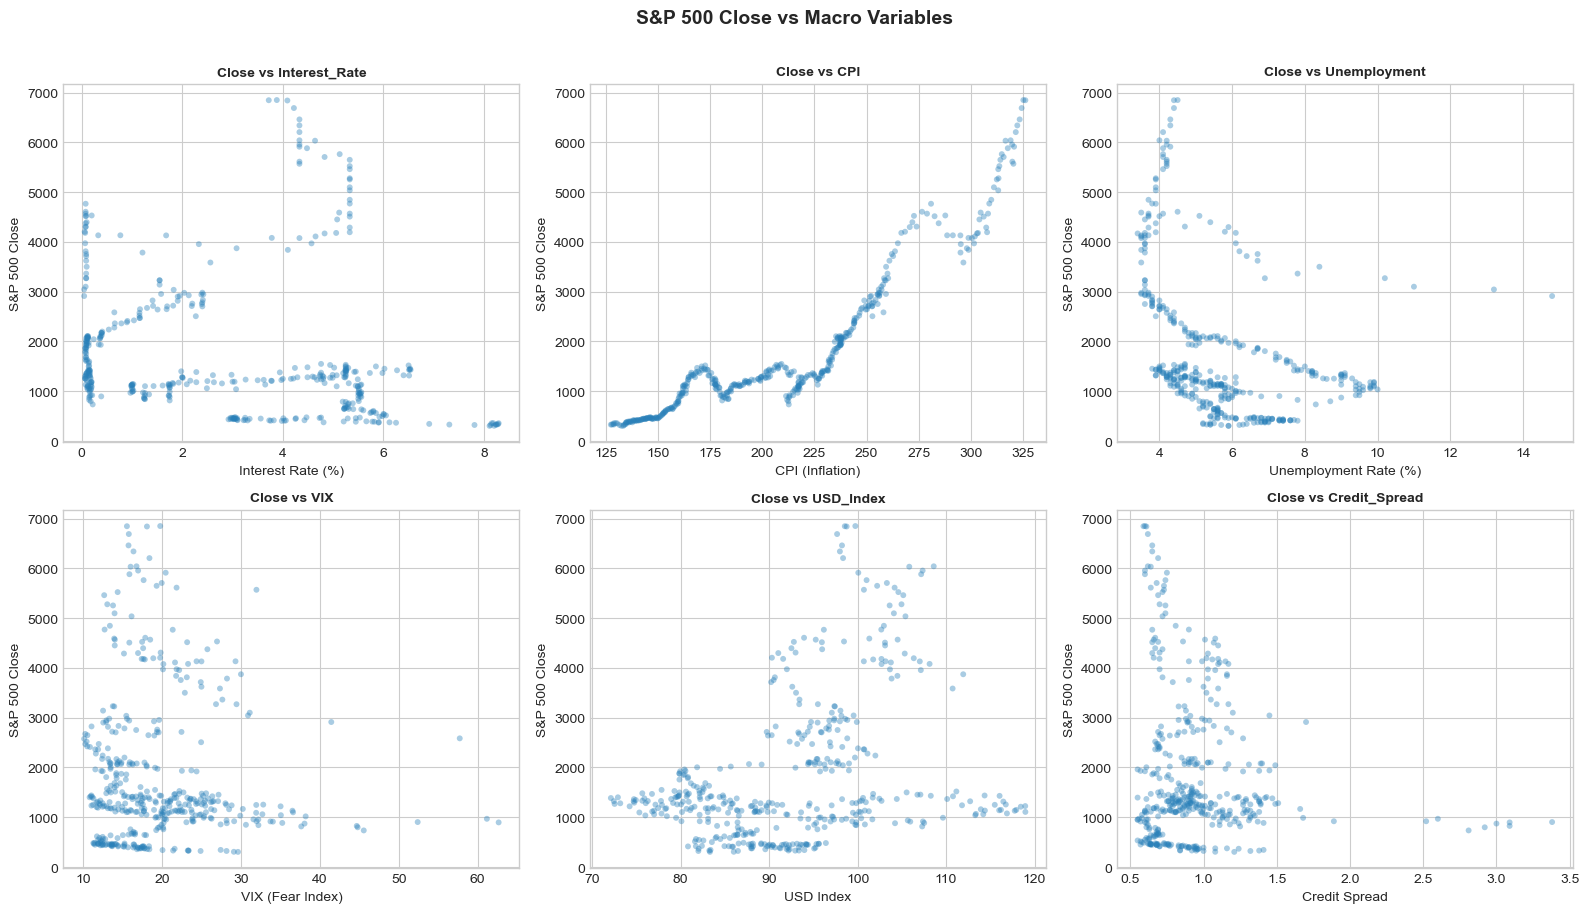

In [11]:
scatter_vars = [
    ("Interest_Rate", "Interest Rate (%)"),
    ("CPI",           "CPI (Inflation)"),
    ("Unemployment",  "Unemployment Rate (%)"),
    ("VIX",           "VIX (Fear Index)"),
    ("USD_Index",     "USD Index"),
    ("Credit_Spread", "Credit Spread"),
]
fig, axes = plt.subplots(2, 3, figsize=(16, 9))
axes = axes.flatten()

for ax, (col, label) in zip(axes, scatter_vars):
    data = df[["SP500_Close", col]].dropna()
    ax.scatter(data[col], data["SP500_Close"], alpha=0.4, s=18,
               color="#2980b9", edgecolors="none")

    # Add a trend line
    # m, b = np.polyfit(data[col], data["SP500_Close"], 1)
    # x_line = np.linspace(data[col].min(), data[col].max(), 100)
    # ax.plot(x_line, m * x_line + b, color="#e74c3c",
    #         linewidth=1.5, label=f"r = {data.corr().iloc[0,1]:.2f}")

    ax.set(xlabel=label, ylabel="S&P 500 Close")
    ax.set_title(f"Close vs {col}", fontsize=10, fontweight="bold")
    ax.legend(fontsize=8)

plt.suptitle("S&P 500 Close vs Macro Variables",
             fontsize=14, fontweight="bold", y=1.01)
plt.tight_layout()
save("07_scatter_macro_vs_close", "eda")
plt.show()

  Saved ../results/eda/08_vix_vs_close.png


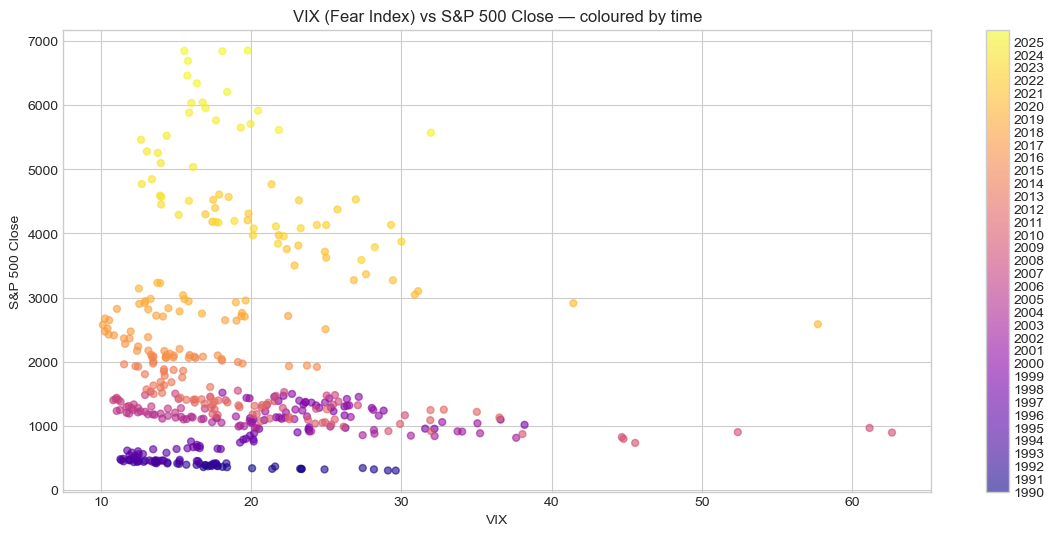

In [12]:
fig, ax = plt.subplots(figsize=FIG_SIZE)
data = df[["SP500_Close", "VIX", "Date"]]
sc = ax.scatter(data["VIX"], data["SP500_Close"],
                c=data["Date"].map(pd.Timestamp.toordinal),
                cmap="plasma", alpha=0.6, s=25)
# plt.colorbar(sc, ax=ax, label="Time (older → newer)")
cbar = plt.colorbar(sc, ax=ax)
years = pd.date_range(data["Date"].min(), data["Date"].max(), freq="YS")

cbar.set_ticks(years.map(pd.Timestamp.toordinal))
cbar.set_ticklabels(years.year)
ax.set(title="VIX (Fear Index) vs S&P 500 Close — coloured by time",
       xlabel="VIX", ylabel="S&P 500 Close")
save("08_vix_vs_close", "eda")
plt.show()


  Saved ../results/eda/09_vix_vs_credit_spread.png


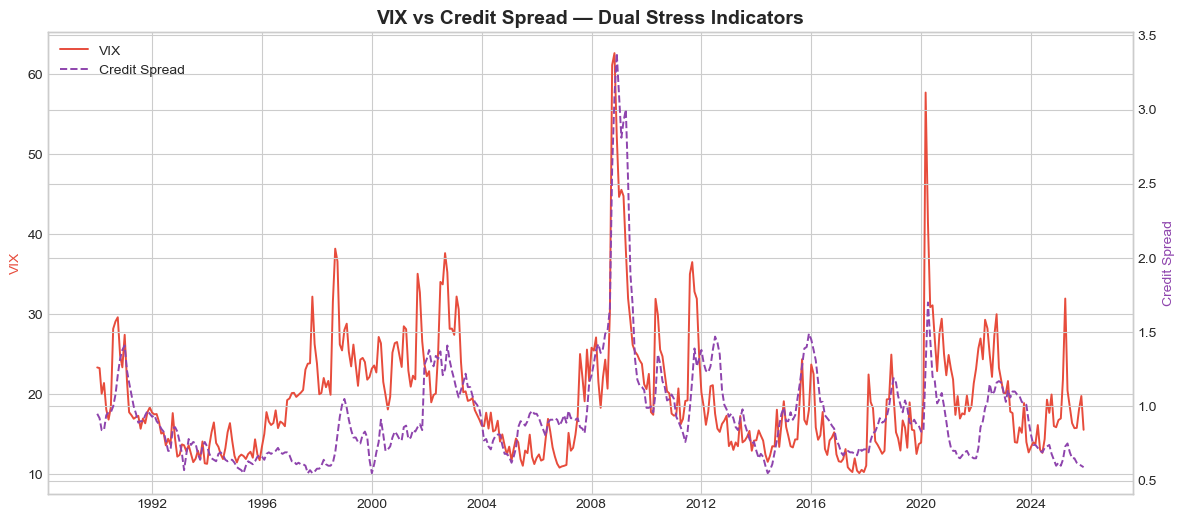

In [13]:
fig, ax1 = plt.subplots(figsize=FIG_SIZE)
ax2 = ax1.twinx()

ax1.plot(df["Date"], df["VIX"],
         color="#e74c3c", linewidth=1.4, label="VIX")
ax2.plot(df["Date"], df["Credit_Spread"],
         color="#8e44ad", linewidth=1.4, linestyle="--", label="Credit Spread")

ax1.set_ylabel("VIX", color="#e74c3c")
ax2.set_ylabel("Credit Spread", color="#8e44ad")
ax1.set_title("VIX vs Credit Spread — Dual Stress Indicators",
              fontsize=14, fontweight="bold")

lines1, labels1 = ax1.get_legend_handles_labels()
lines2, labels2 = ax2.get_legend_handles_labels()
ax1.legend(lines1 + lines2, labels1 + labels2, loc="upper left")
save("09_vix_vs_credit_spread", "eda")
plt.show()